In [1]:
%load_ext autoreload
%autoreload 2

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ---- project imports ----
from sim.frame import make_blank_frame
from sim.render import RenderConfig, render, plot_render_stages
from sim.camera import Camera
from sim.lens import Lens
from sim.mask import Mask
from sim.physics.noise import apply_noise
from sim.frame import display_frame
from sim.frame import plot_star_rois
from sim.physics.stars import load_star_field
from sim.physics.psf import apply_psf

sky median (e-/px): 3.0
stars_post_psf max (e-/px): 3258.188720703125
final mean/var (small patch): 3.2501392364501953 87.08599853515625
catalog stars: 65263 | on-sensor: 517


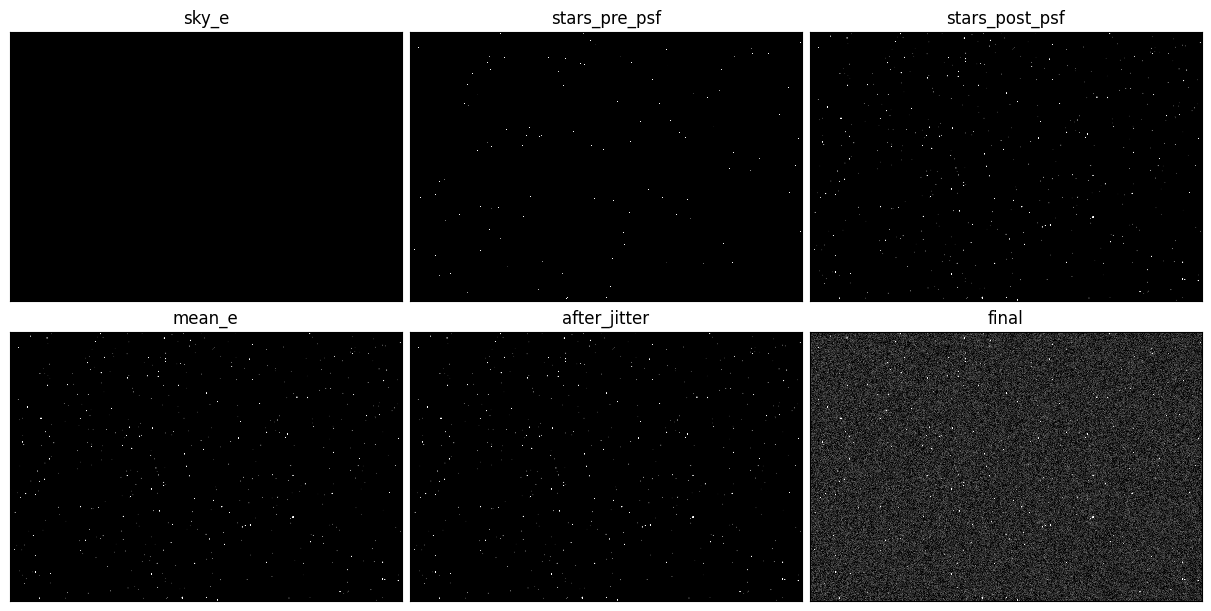

In [16]:
STAR_CSV = "sim/physics/starfields/field2.csv"

# Pointing (match your downloaded field)
RA0_DEG  = 40.0
DEC0_DEG = 70.0
ROT_DEG  = 0.0

# Camera + lens
cam = Camera(
    nx=1920,
    ny=1080,
    pixel_um=3.75,
    read_noise_e=5,
    gain_e_per_adu=1.0,
    qe=0.6,
)

lens = Lens(
    focal_mm=120.0,
    f_number=2.0,
    transmission=0.9
)

# Blank frame
frame = make_blank_frame(cam, lens, ra0_deg=RA0_DEG, dec0_deg=DEC0_DEG, rot_deg=ROT_DEG)

# Render config:
# - derived star ZP (zeropoint_e_per_s=0)
# - derived sky from mu (sky_e_per_px_s=0)
# - PSF + jitter + noise on
# - mask object present but kind="none" => no change (plumbing test)
cfg = RenderConfig(
    exposure_s=1.0,
    sky_mu_mag_per_arcsec2=21.0,
    zeropoint_e_per_s=0.0,
    lambda_eff_nm=550.0,
    band_nm=90.0,

    psf_sigma_px=1.2,
    mask=Mask(
        kind="grating",
        angle_deg=25.0,
        lines_per_mm=150.0,
        order_max=1,
        order_rel_amp=0.12,
    ),

    enable_psf=True,
    enable_noise=True,
    enable_jitter=False,
    seed=42,
)
frame, res = render(frame, cfg, stars=STAR_CSV)

# Visualize stages (your updated plot_render_stages should be 2x3)
plot_render_stages(frame, res, cmap="gray", stretch="asinh", shared_scale=True)

# Quick numeric checks
print("sky median (e-/px):", float(np.median(res.sky_e)))
print("stars_post_psf max (e-/px):", float(np.max(res.stars_e_post_psf)))
print("final mean/var (small patch):",
      float(np.mean(res.final_e[200:400, 200:400])),
      float(np.var(res.final_e[200:400, 200:400])))

# Optional: confirm how many catalog stars land on sensor
sf = load_star_field(STAR_CSV)
x_px, y_px = frame.radec_to_pixel(sf.ra_deg, sf.dec_deg)
on = (x_px >= 0) & (x_px < cam.nx) & (y_px >= 0) & (y_px < cam.ny)
print("catalog stars:", len(sf.ra_deg), "| on-sensor:", int(on.sum()))

Predicted ±1 separation (px): 211.2


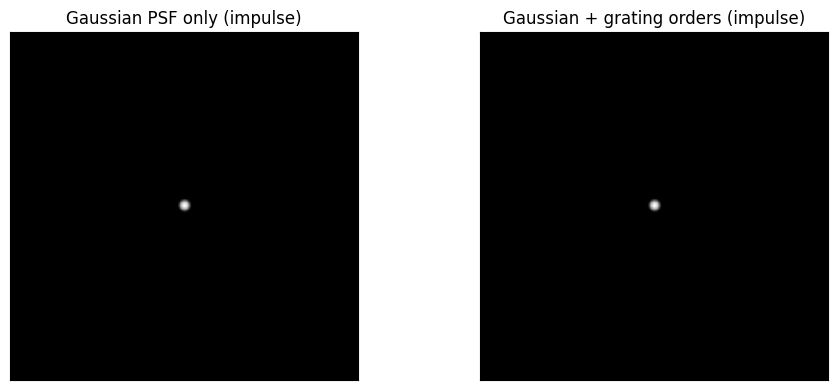

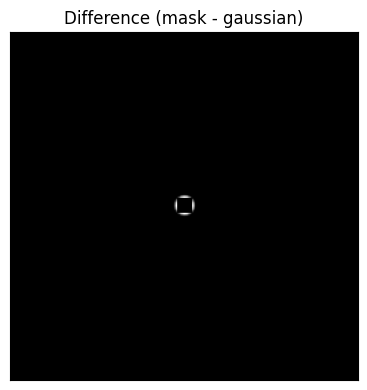

In [24]:
# --- helper: predict order separation in px ---
def predict_order_sep_px(frame, cfg, mask, m=1):
    lines_per_mm = float(getattr(mask, "lines_per_mm", 0.0))
    if lines_per_mm <= 0:
        return np.nan
    pitch_mm = 1.0 / lines_per_mm
    lam_mm = float(getattr(cfg, "lambda_eff_nm", 550.0)) * 1e-6  # nm->mm
    f_mm = float(frame.lens.focal_mm)
    pix_mm = float(frame.camera.pixel_um) * 1e-3
    theta = m * (lam_mm / pitch_mm)          # small-angle
    sep_mm = f_mm * theta
    return sep_mm / pix_mm

# --- make a tiny test image with one "star" impulse ---
ny, nx = 256, 256
imp = np.zeros((ny, nx), dtype=np.float32)
cy, cx = ny // 2, nx // 2
imp[cy, cx] = 1.0e6  # huge so faint orders appear

# --- configs (explicit, simple) ---
cfg_gauss = RenderConfig(
    exposure_s=1.0,
    sky_e_per_px_s=0.0,
    sky_mu_mag_per_arcsec2=21.0,
    zeropoint_e_per_s=0.0,
    lambda_eff_nm=550.0,
    band_nm=90.0,
    psf_sigma_px=1.2,
    mask=Mask(kind="none"),
    enable_sky=False,
    enable_stars=False,
    enable_psf=True,
    enable_jitter=False,
    enable_noise=False,
    seed=0,
)

cfg_mask = RenderConfig(
    exposure_s=1.0,
    sky_e_per_px_s=0.0,
    sky_mu_mag_per_arcsec2=21.0,
    zeropoint_e_per_s=0.0,
    lambda_eff_nm=550.0,
    band_nm=90.0,
    psf_sigma_px=1.2,
    mask=Mask(
        kind="grating",
        angle_deg=25.0,
        lines_per_mm=12.0,     # <<< IMPORTANT: visible on sensor for f=120mm
        order_max=1,
        order_rel_amp=0.12,
    ),
    enable_sky=False,
    enable_stars=False,
    enable_psf=True,
    enable_jitter=False,
    enable_noise=False,
    seed=0,
)

print("Predicted ±1 separation (px):", predict_order_sep_px(frame, cfg_mask, cfg_mask.mask, m=1))

img_gauss = apply_psf(imp, frame, cfg_gauss)
img_mask  = apply_psf(imp, frame, cfg_mask)

# --- display with aggressive asinh stretch ---
def show(img, title):
    a = img.astype(np.float64)
    ped = np.percentile(a[np.isfinite(a)], 1.0)
    a = np.clip(a - ped, 0, None)
    s = np.percentile(a[a > 0], 99.9) if np.any(a > 0) else 1.0
    disp = np.arcsinh(a / max(s, 1e-12))
    plt.imshow(disp, origin="lower", cmap="gray")
    plt.title(title)
    plt.xticks([]); plt.yticks([])

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); show(img_gauss, "Gaussian PSF only (impulse)")
plt.subplot(1, 2, 2); show(img_mask,  "Gaussian + grating orders (impulse)")
plt.tight_layout()
plt.show()

# difference view
plt.figure(figsize=(5, 4))
show(img_mask - img_gauss, "Difference (mask - gaussian)")
plt.tight_layout()
plt.show()

Predicted ±1 separation (px): 211.2


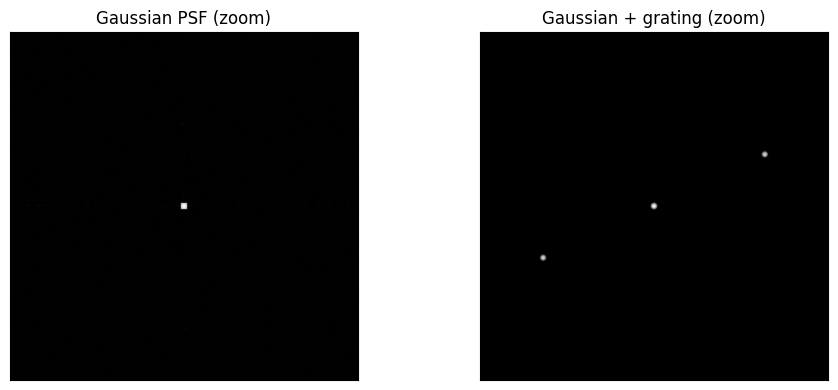

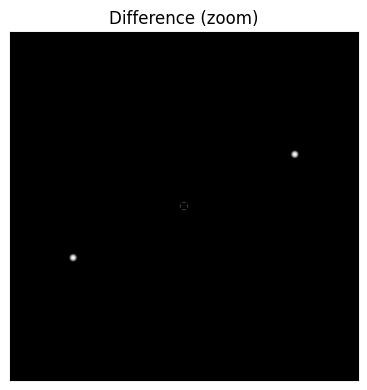

In [26]:
ny, nx = 700, 700
imp = np.zeros((ny, nx), dtype=np.float32)
cy, cx = ny//2, nx//2
imp[cy, cx] = 1.0e6

print("Predicted ±1 separation (px):", predict_order_sep_px(frame, cfg_mask, cfg_mask.mask, m=1))

img_gauss = apply_psf(imp, frame, cfg_gauss)
img_mask  = apply_psf(imp, frame, cfg_mask)

# show a zoomed window that includes the orders
half_show = 300  # > 211
y1, y2 = cy-half_show, cy+half_show+1
x1, x2 = cx-half_show, cx+half_show+1

def show(img, title):
    a = img[y1:y2, x1:x2].astype(np.float64)
    ped = np.percentile(a, 1.0)
    a = np.clip(a - ped, 0, None)
    s = np.percentile(a[a > 0], 99.9) if np.any(a > 0) else 1.0
    disp = np.arcsinh(a / max(s, 1e-12))
    plt.imshow(disp, origin="lower", cmap="gray")
    plt.title(title)
    plt.xticks([]); plt.yticks([])

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); show(img_gauss, "Gaussian PSF (zoom)")
plt.subplot(1,2,2); show(img_mask,  "Gaussian + grating (zoom)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
show(img_mask - img_gauss, "Difference (zoom)")
plt.tight_layout()
plt.show()

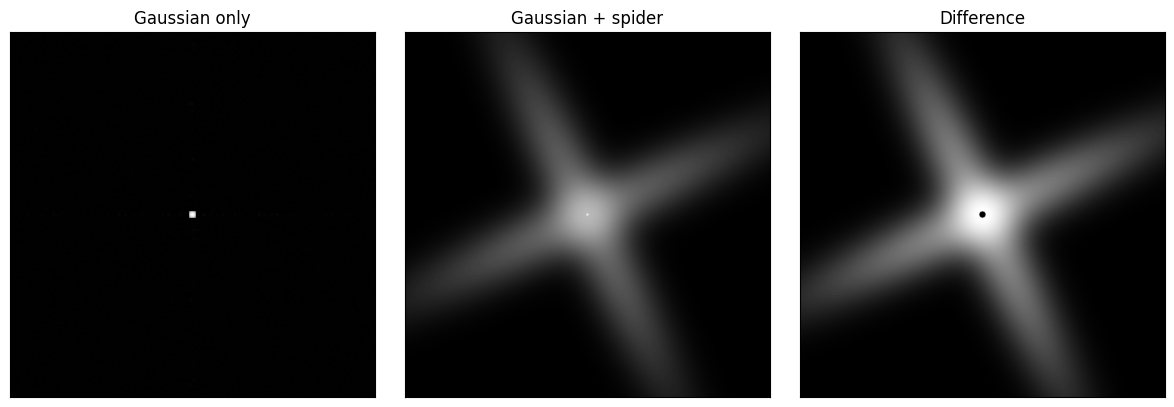

In [27]:
ny, nx = 900, 900
imp = np.zeros((ny, nx), dtype=np.float32)
cy, cx = ny//2, nx//2
imp[cy, cx] = 1e6

cfg_gauss = RenderConfig(
    exposure_s=1.0,
    sky_e_per_px_s=0.0,
    sky_mu_mag_per_arcsec2=21.0,
    zeropoint_e_per_s=0.0,
    lambda_eff_nm=550.0,
    band_nm=90.0,
    psf_sigma_px=1.2,
    mask=Mask(kind="none"),
    enable_sky=False, enable_stars=False, enable_psf=True,
    enable_jitter=False, enable_noise=False,
)

cfg_spider = RenderConfig(
    exposure_s=1.0,
    sky_e_per_px_s=0.0,
    sky_mu_mag_per_arcsec2=21.0,
    zeropoint_e_per_s=0.0,
    lambda_eff_nm=550.0,
    band_nm=90.0,
    psf_sigma_px=1.2,
    mask=Mask(
        kind="spider",
        angle_deg=25.0,
        n_vanes=2,
        vane_width_mm=0.5,
        spike_radius_px=350,
        spike_rel_amp=0.2,
    ),
    enable_sky=False, enable_stars=False, enable_psf=True,
    enable_jitter=False, enable_noise=False,
)

img_gauss = apply_psf(imp, frame, cfg_gauss)
img_sp    = apply_psf(imp, frame, cfg_spider)

def show_zoom(img, title, half=300):
    a = img[cy-half:cy+half+1, cx-half:cx+half+1].astype(np.float64)
    ped = np.percentile(a, 1.0)
    a = np.clip(a - ped, 0, None)
    s = np.percentile(a[a > 0], 99.9) if np.any(a > 0) else 1.0
    disp = np.arcsinh(a / max(s, 1e-12))
    plt.imshow(disp, origin="lower", cmap="gray")
    plt.title(title)
    plt.xticks([]); plt.yticks([])

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); show_zoom(img_gauss, "Gaussian only")
plt.subplot(1,3,2); show_zoom(img_sp, "Gaussian + spider")
plt.subplot(1,3,3); show_zoom(img_sp - img_gauss, "Difference")
plt.tight_layout()
plt.show()

spider v1: spike_sigma_perp_px ~ 11.73 px  (smaller => thinner)
stars_post_psf max (e-/px): 59.00909423828125
final mean/var (small patch): 2.5323686599731445 27.782630920410156


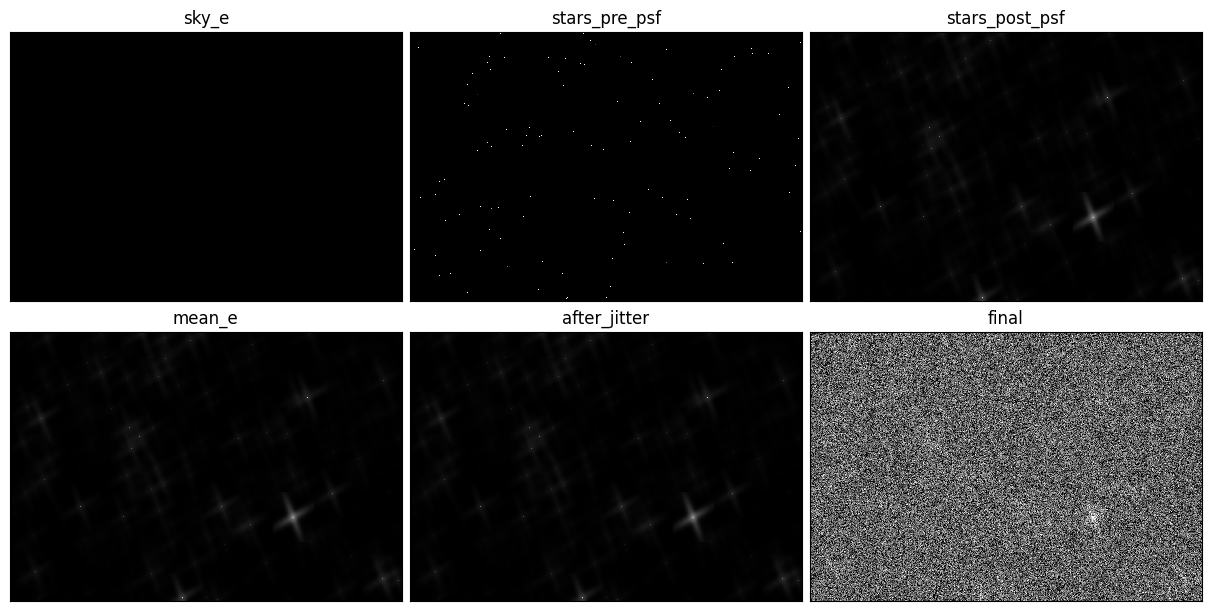

In [32]:
import numpy as np

STAR_CSV = "sim/physics/starfields/field2.csv"

RA0_DEG  = 40.0
DEC0_DEG = 70.0
ROT_DEG  = 0.0

cam = Camera(
    nx=1920,
    ny=1080,
    pixel_um=3.75,
    read_noise_e=5.0,
    gain_e_per_adu=1.0,
    qe=0.6,
)

lens = Lens(
    focal_mm=120.0,
    f_number=2.0,
    transmission=0.9
)

frame = make_blank_frame(cam, lens, ra0_deg=RA0_DEG, dec0_deg=DEC0_DEG, rot_deg=ROT_DEG)

# --- realistic-ish spider settings ---
# For this v1 kernel model:
#   - spike_rel_amp should be small (try 0.01–0.05)
#   - spike_radius_px moderate (150–300)
#   - vane_width_mm larger => thinner spike (per our slit-width scaling)

spider_mask = Mask(
    kind="spider",
    angle_deg=25.0,
    n_vanes=2,            # cross (+) = two orthogonal lines
    vane_width_mm=1.5,    # try 0.8–2.5 ; larger => thinner spikes in this model
    transmission=0.0,

    spike_radius_px=100,  # controls how far spikes extend in kernel
    spike_rel_amp=0.02,   # controls spike strength (THIS is the big one)
)

cfg = RenderConfig(
    exposure_s=1.0,
    sky_e_per_px_s=0.0,
    sky_mu_mag_per_arcsec2=21.0,
    zeropoint_e_per_s=0.0,
    lambda_eff_nm=550.0,
    band_nm=90.0,

    psf_sigma_px=1.2,
    mask=spider_mask,

    enable_sky=True,
    enable_stars=True,
    enable_psf=True,
    enable_jitter=False,
    enable_noise=True,

    seed=42
)

# --- optional: print the spike thickness scale being used by the model ---
# (copied from your masks.py logic; matches the kernel builder)
f_mm   = frame.lens.focal_mm
pix_mm = frame.camera.pixel_um * 1e-3
lam_mm = cfg.lambda_eff_nm * 1e-6
w_mm   = spider_mask.vane_width_mm
perp_scale_mm = f_mm * (lam_mm / max(w_mm, 1e-9))
spike_sigma_perp_px = max(0.5, perp_scale_mm / max(pix_mm, 1e-12))
print(f"spider v1: spike_sigma_perp_px ~ {spike_sigma_perp_px:.2f} px  (smaller => thinner)")

frame, res = render(frame, cfg, stars=STAR_CSV)

plot_render_stages(frame, res, cmap="gray", stretch="asinh", shared_scale=True)

print("stars_post_psf max (e-/px):", float(np.max(res.stars_e_post_psf)))
print("final mean/var (small patch):",
      float(np.mean(res.final_e[200:400, 200:400])),
      float(np.var(res.final_e[200:400, 200:400])))

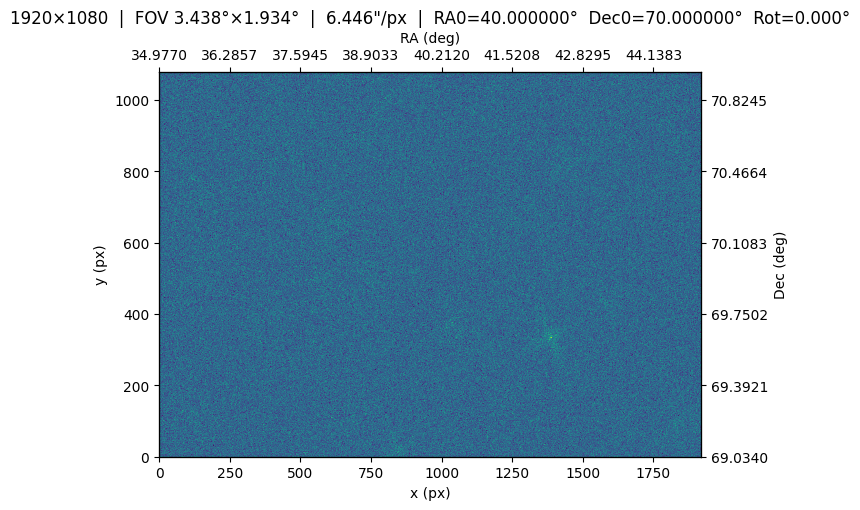

In [33]:
display_frame(frame)

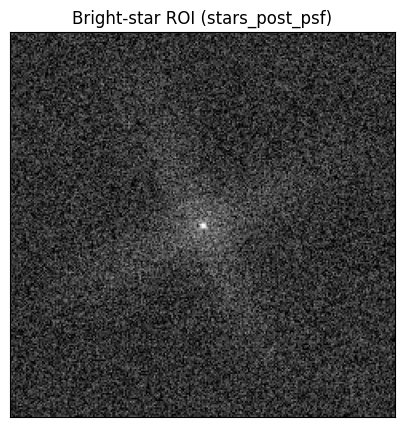

In [35]:
img = res.final_e.astype(np.float64)
y0, x0 = np.unravel_index(np.argmax(img), img.shape)

half = 120
patch = img[max(0,y0-half):y0+half+1, max(0,x0-half):x0+half+1]

ped = np.percentile(patch, 5.0)
p = np.clip(patch - ped, 0, None)
s = np.percentile(p[p > 0], 99.9) if np.any(p > 0) else 1.0
disp = np.arcsinh(p / max(s, 1e-12))

plt.figure(figsize=(5,5))
plt.imshow(disp, origin="lower", cmap="gray")
plt.title("Bright-star ROI (stars_post_psf)")
plt.xticks([]); plt.yticks([])
plt.show()

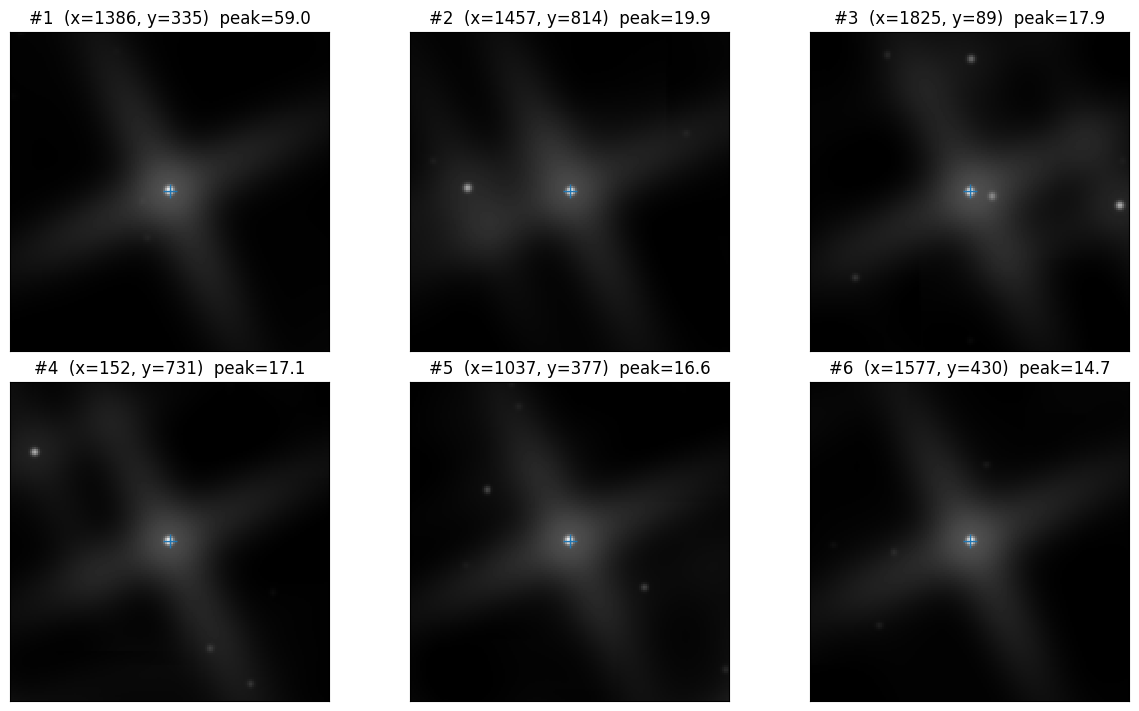

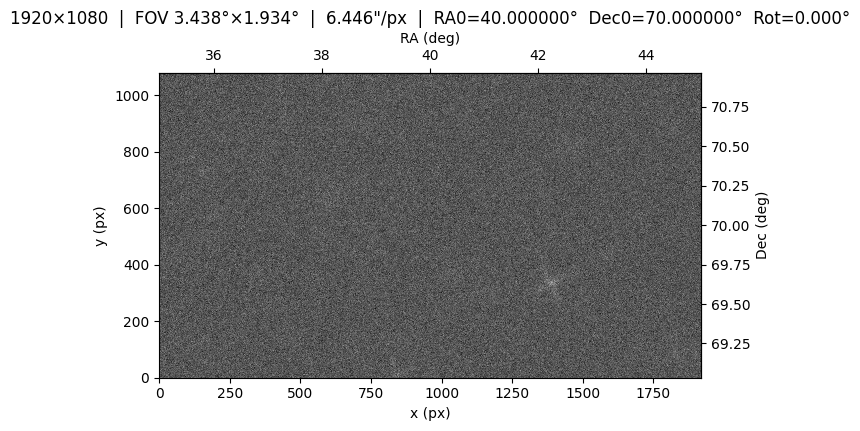

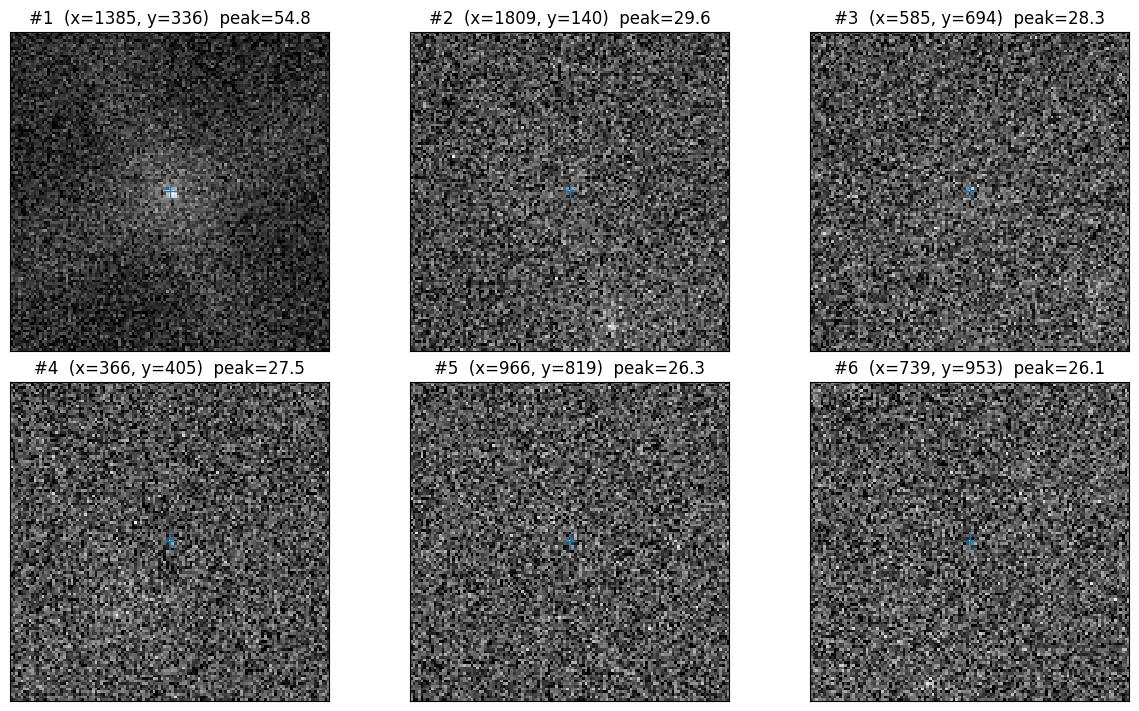

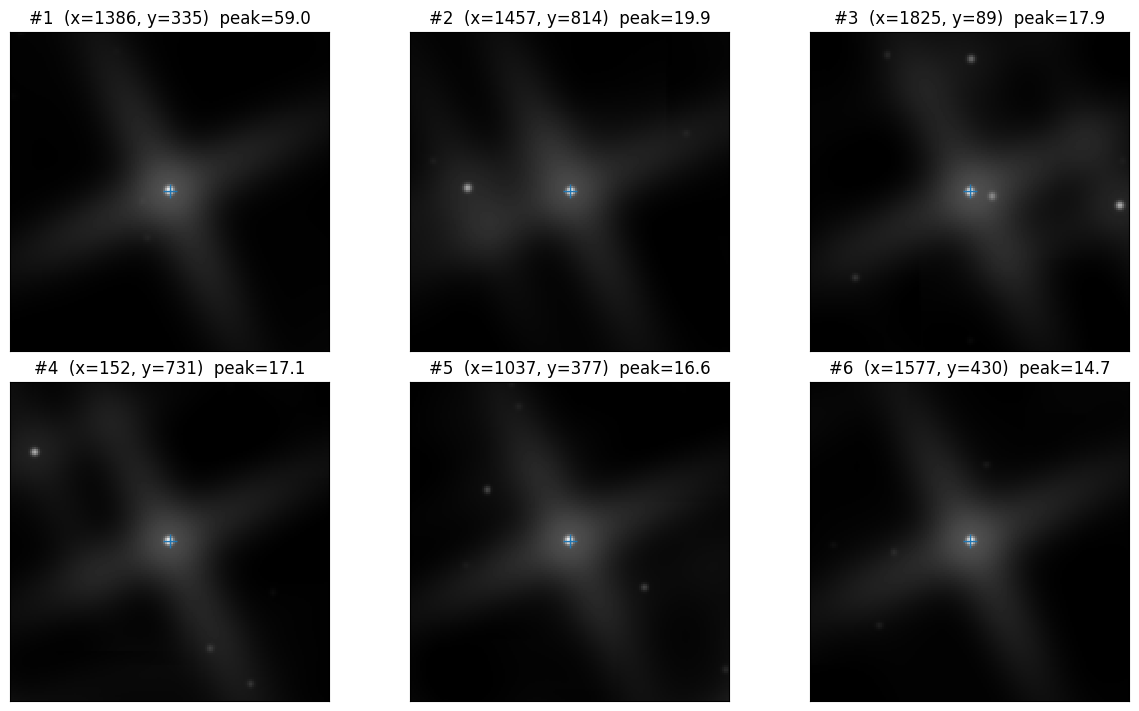

In [37]:
# full-frame display (grayscale + correct aspect + RA/Dec)
display_frame(frame, cmap="gray", show_ra_dec=True)

# show ROIs for the FINAL frame (including sky+noise)
plot_star_rois(frame, image=res.final_e, n=6, half_size=60, min_sep_px=80, stretch="asinh")

# show ROIs for stars-only post-PSF (best for seeing spikes cleanly)
plot_star_rois(frame, image=res.stars_e_post_psf, n=6, half_size=80, min_sep_px=120, stretch="asinh")